# Continuous Time Quantum Walks

## Ring Topology

Once again, we introduce the position operator, and the evolution hamiltonian:

In [2]:
import numpy as np                          # linear algebra

ring_size = 200

x = np.zeros(ring_size, dtype=np.complex128)  # position vector
x[ring_size//2] = 1

state = x

Tails = -1*np.eye(ring_size, k=-1, dtype=np.complex128)
Heads = -1*np.eye(ring_size, k=1, dtype=np.complex128)
Diag = 2*np.eye(ring_size, dtype=np.complex128)

a = np.zeros((ring_size, ring_size), dtype=np.complex128)
a[ring_size-1, 0] = -1

b = np.zeros((ring_size, ring_size), dtype=np.complex128)
b[0, ring_size-1] = -1

gamma = 0.5

Shift = gamma * (Tails + Heads + Diag + a + b) # sum of all the shifts caused by heads or tails, plus the boundary conditions to make it an actual ring

def Shrodinger(t, state) : 
    dstate =-1j * Shift@state
    return dstate

We import a differential equation solver.

In [3]:
from scipy.integrate import solve_ivp

endtime = 50
t_eval = np.arange(0, endtime, 0.1)
sol = solve_ivp(Shrodinger, [0, endtime], state, t_eval=t_eval, method='RK45')

We measure the position probabilities and plot the final results.

In [4]:
def Measure_pos(state):
    positions = np.zeros(ring_size)

    for i, x in enumerate(state):
        if x != 0:
            positions[i] += abs(x)**2

    return positions

pos = Measure_pos(sol.y[:, -1])

Text(0.5, 1.0, 'Probability distribution at t=50')

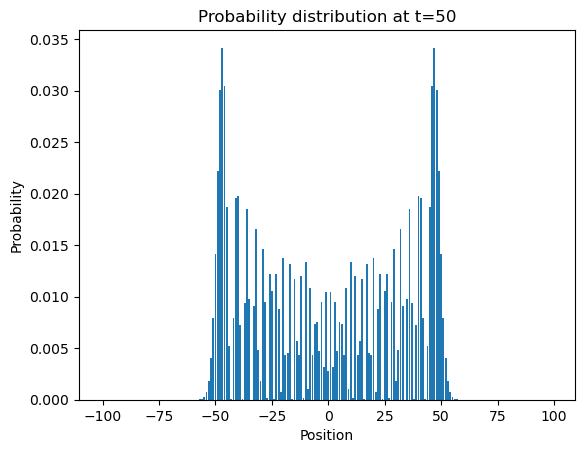

In [5]:
import matplotlib.pyplot as plt

plt.bar(np.arange(len(pos)) - ring_size//2, pos)

plt.xlabel("Position")
plt.ylabel("Probability")
plt.title('Probability distribution at t=50')

Since we have the Hamiltonian, we can obtain the final state by just calculating

$$ \ket{\psi(t)} = \hat{U}(t) \ket{\psi(0)}$$

with $\hat{U}(t) = e^{-i \hat{H} t}$ the time evolution operator.

In [6]:
from scipy.linalg import expm

def Evol_vector(t, state, hamiltonian):
    return expm(-1j * hamiltonian * t) @ state

In [7]:
f_state = Evol_vector(50, state, Shift)

In [8]:
pos_operator = Measure_pos(f_state)

Text(0.5, 1.0, 'Operator evolved evolution')

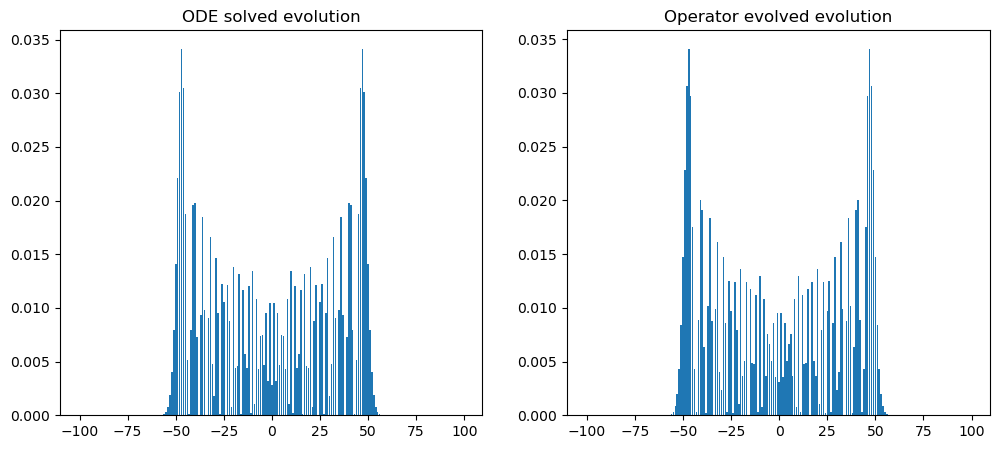

In [9]:
import matplotlib.pyplot as plt

fig, (p1, p2) = plt.subplots(1, 2, figsize=(12, 5))

p1.bar(np.arange(len(pos)) - ring_size//2, pos)

p1.set_title("ODE solved evolution")

p2.bar(np.arange(len(pos_operator)) - ring_size//2, pos_operator)

p2.set_title("Operator evolved evolution")

### Density Matrix

The reason is that we can more easily understand the dephasing, which means, the change from superposition to statistical mixture.

In [10]:
import numpy as np                          # linear algebra

ring_size = 200

x = np.zeros(ring_size, dtype=np.complex128)  # position vector
x[ring_size//2] = 1

state = np.outer(x, x)

Tails = -1*np.eye(ring_size, k=-1, dtype=np.complex128)
Heads = -1*np.eye(ring_size, k=1, dtype=np.complex128)
Diag = 2*np.eye(ring_size, dtype=np.complex128)

a = np.zeros((ring_size, ring_size), dtype=np.complex128)
a[ring_size-1, 0] = -1

b = np.zeros((ring_size, ring_size), dtype=np.complex128)
b[0, ring_size-1] = -1

gamma = 0.5

Shift = gamma * (Tails + Heads + Diag + a + b) # sum of all the shifts caused by heads or tails, plus the boundary conditions to make it an actual ring

def VNeumann(t, state) :

    rho = state.reshape((ring_size, ring_size))
    dstate = -1j * (Shift @ rho - rho @ Shift)
    return dstate.flatten()

In [11]:
def Measure_pos(state):
   
    return np.real(np.diag(state.reshape((ring_size, ring_size))))

# The original code had a loop in which I'd build a projector on every position
# And then calculate the trace, put it in another vector, and return that.

# But just taking the real part of the diagonal of the matrix is the exact same thing, so...

Once again, first we integrate the equation, and then we evolve it via unitary operator. One is way faster (and probably way more accurate) than the other...

In [12]:
from scipy.integrate import solve_ivp

endtime = 50
t_eval = np.arange(0, endtime, 0.1)
sol = solve_ivp(VNeumann, [0, endtime], state.flatten(), t_eval=t_eval, method='RK45')

In [13]:
pos = Measure_pos(sol.y[:, -1])

In [14]:
from scipy.linalg import expm

def Evol(t, state, hamiltonian):
    operator = expm(-1j * hamiltonian * t)
    return operator @ state @ operator.conj().T

In [15]:
f_state = Evol(50, state, Shift)
pos_operator = Measure_pos(f_state)

Text(0.5, 1.0, 'Operator evolved evolution')

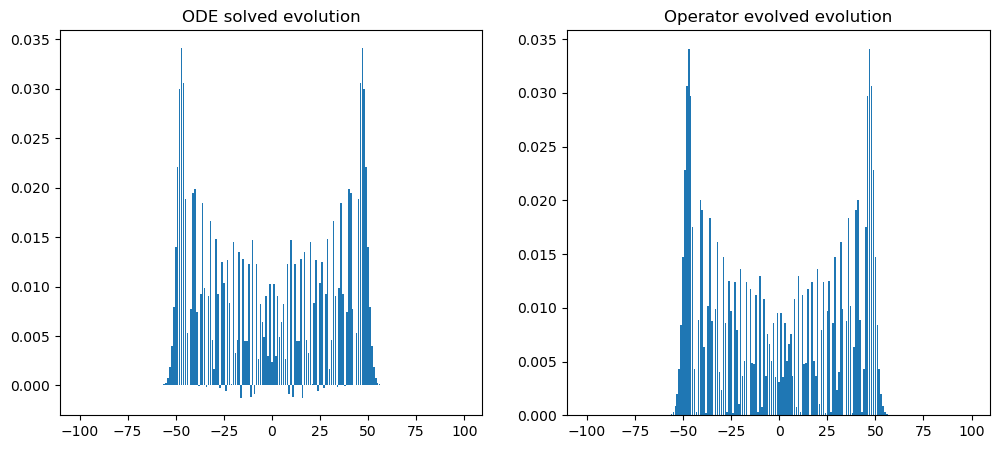

In [16]:
import matplotlib.pyplot as plt

fig, (p1, p2) = plt.subplots(1, 2, figsize=(12, 5))

p1.bar(np.arange(len(pos)) - ring_size//2, pos)

p1.set_title("ODE solved evolution")

p2.bar(np.arange(len(pos_operator)) - ring_size//2, pos_operator)

p2.set_title("Operator evolved evolution")

Somehow, the integration produced negative probabilities. We figured out which approach is better.

### Laplacian and Adjacence Matrix

We want to show that if we use the Laplacian or the Adjacence Matrix, the result is the same.

In [17]:
import numpy as np                          # linear algebra

ring_size = 15

x = np.zeros(ring_size, dtype=np.complex128)  # position vector
x[ring_size//2] = 1

state = x

Tails = -1*np.eye(ring_size, k=-1, dtype=np.complex128)
Heads = -1*np.eye(ring_size, k=1, dtype=np.complex128)
Diag = 2*np.eye(ring_size, dtype=np.complex128)

a = np.zeros((ring_size, ring_size), dtype=np.complex128)
a[ring_size-1, 0] = -1

b = np.zeros((ring_size, ring_size), dtype=np.complex128)
b[0, ring_size-1] = -1

gamma = 1

Laplace = gamma * (Tails + Heads + Diag + a + b)

Adjacence = gamma * (-Tails -Heads - a - b)

In [18]:
from scipy.linalg import expm

def Evol_vector(t, state, hamiltonian):
    return expm(-1j * hamiltonian * t) @ state

def Measure_pos(state):
    positions = np.zeros(ring_size)

    for i, x in enumerate(state):
        if x != 0:
            positions[i] += abs(x)**2

    return positions

In [19]:
Laplace_state = Evol_vector(50, state, Laplace)

Adjacence_state = Evol_vector(50, state, Adjacence)

pos_Laplace = Measure_pos(Laplace_state)
pos_Adj = Measure_pos(Adjacence_state)

Text(0.5, 1.0, 'Adjacence')

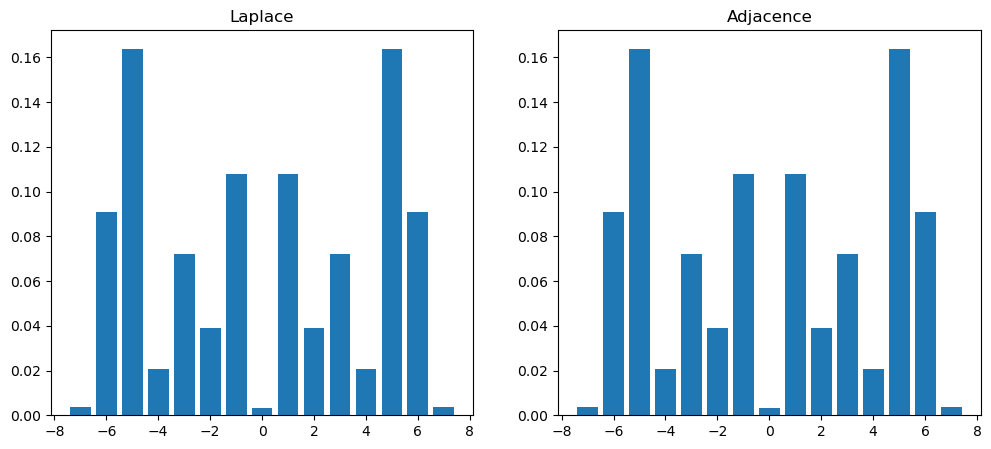

In [20]:
import matplotlib.pyplot as plt

fig, (p1, p2) = plt.subplots(1, 2, figsize=(12, 5))

p1.bar(np.arange(len(pos_Laplace)) - ring_size//2, pos_Laplace)

p1.set_title("Laplace")

p2.bar(np.arange(len(pos_Adj)) - ring_size//2, pos_Adj)

p2.set_title("Adjacence")

In [21]:
def Measure_site(state, site, t, steps, hamiltonian):
    population = np.zeros(steps)

    increment = t/steps

    for i in range(steps):
        x = Evol_vector(i * increment, state, hamiltonian)
        population[i] = abs(x[site])**2

    return population

Laplace_origin = Measure_site(state, ring_size//2, 10, 50, Laplace)
Adj_origin = Measure_site(state, ring_size//2, 10, 50, Adjacence)

Text(0.5, 1.0, 'Adjacence')

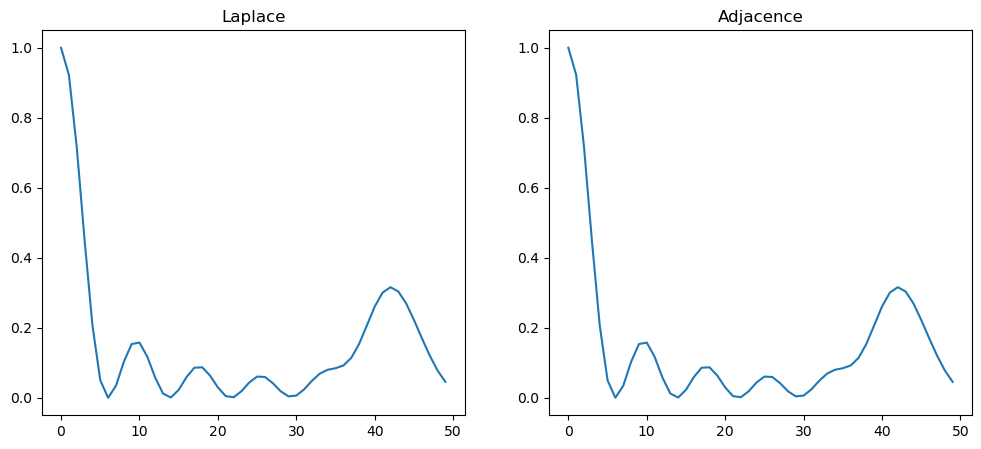

In [22]:
import matplotlib.pyplot as plt

fig, (p1, p2) = plt.subplots(1, 2, figsize=(12, 5))

p1.plot(np.arange(len(Laplace_origin)), Laplace_origin)

p1.set_title("Laplace")

p2.plot(np.arange(len(Adj_origin)), Adj_origin)

p2.set_title("Adjacence")

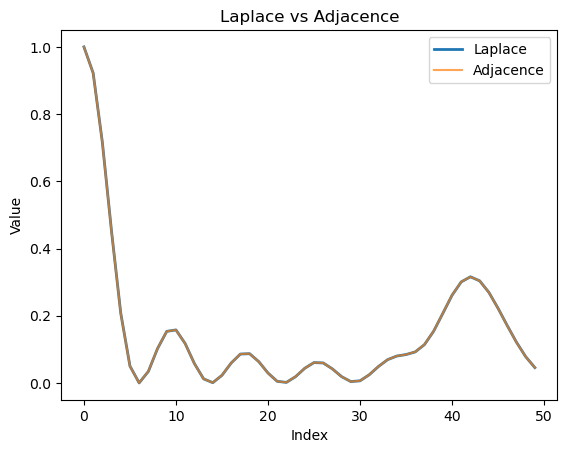

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Create a single plot (1 row, 1 column)
fig, ax = plt.subplots()

# Plot the first dataset
ax.plot(np.arange(len(Laplace_origin)), Laplace_origin, label="Laplace", linewidth=2)

# Plot the second dataset on the same 'ax'
ax.plot(np.arange(len(Adj_origin)), Adj_origin, label="Adjacence", alpha=0.7)

# Add styling and clarity
ax.set_title("Laplace vs Adjacence")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.legend() # This shows the labels we defined in the plot calls

plt.show()

## Star (and Fully Connected)

In [59]:
import numpy as np                          # linear algebra

graph_size = 6

x = np.zeros(graph_size, dtype=np.complex128)  # position vector
x[0] = 1

state = x

Adjacence_star = np.zeros((graph_size, graph_size), dtype=np.complex128)

for i in range(graph_size-1):
    Adjacence_star[0, i+1] = 1
    Adjacence_star[i+1, 0] = 1

diagonal = np.eye(graph_size, dtype=np.complex128)

diagonal[0, 0] = graph_size - 1


gamma = 1

Laplace_star = gamma * (diagonal - Adjacence_star)


In [60]:
from scipy.linalg import expm

def Evol_vector(t, state, hamiltonian):
    return expm(-1j * hamiltonian * t) @ state

def Measure_pos(state):
    positions = np.zeros(state.size)

    for i, x in enumerate(state):
        if x != 0:
            positions[i] += abs(x)**2

    return positions

In [61]:
Laplace_state = Evol_vector(10, state, Laplace_star)

pos_Laplace = Measure_pos(Laplace_state)

Text(0.5, 1.0, 'Laplace')

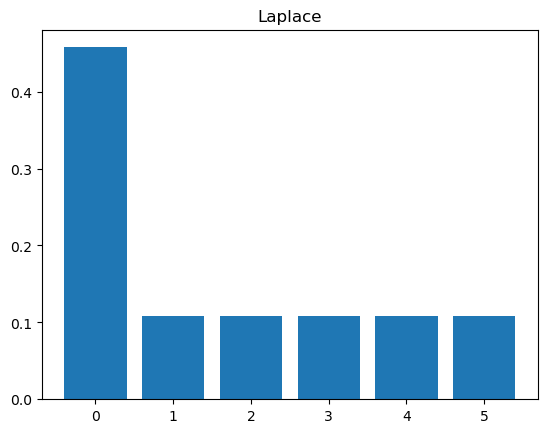

In [62]:
import matplotlib.pyplot as plt

plt.bar(np.arange(len(pos_Laplace)), pos_Laplace)

plt.title("Laplace")

Now we fully connect it

In [63]:
import numpy as np                          # linear algebra

graph_size = 6

x = np.zeros(graph_size, dtype=np.complex128)  # position vector
x[0] = 1

state = x

Adj_conn = np.zeros((graph_size, graph_size), dtype=np.complex128)

Adj_conn.fill(1)

Adj_conn = Adj_conn - np.identity(graph_size)

diagonal = np.zeros((graph_size, graph_size), dtype=np.complex128)

for i in range (graph_size):
    diagonal[i, i] = graph_size - 1


gamma = 1

Laplace_conn = gamma * (diagonal - Adj_conn)


In [64]:
t = 15

State_conn = Evol_vector(t, state, Laplace_conn)

pos_conn = Measure_pos(State_conn)

Laplace_state = Evol_vector(t, state, Laplace_star)

pos_Laplace = Measure_pos(Laplace_state)

Text(0.5, 1.0, 'Connected')

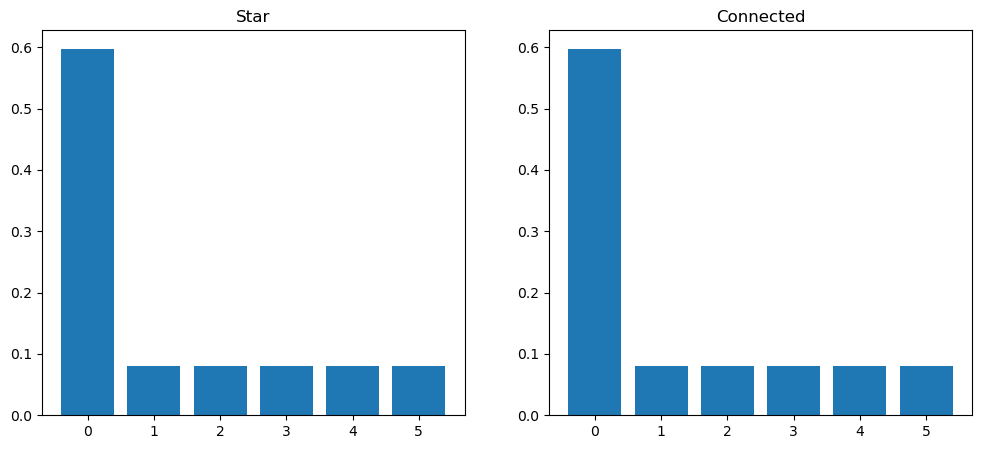

In [65]:
import matplotlib.pyplot as plt

fig, (p1, p2) = plt.subplots(1, 2, figsize=(12, 5))

p1.bar(np.arange(len(pos_Laplace)), pos_Laplace)

p1.set_title("Star")

p2.bar(np.arange(len(pos_conn)), pos_conn)

p2.set_title("Connected")

In [66]:
Star_origin = Measure_site(state, 0, 10, 1000, Laplace_star)
Conn_origin = Measure_site(state, 0, 10, 1000, Laplace_conn)

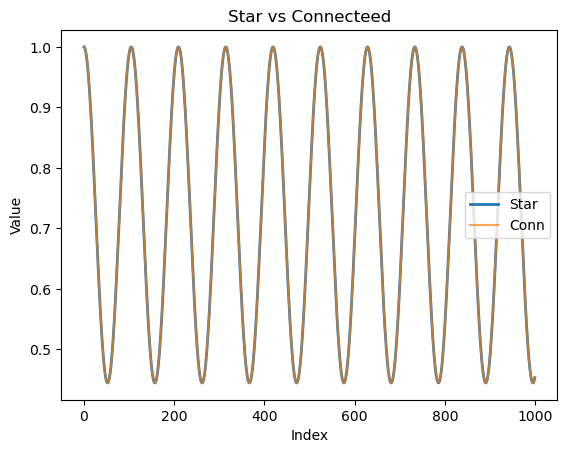

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Create a single plot (1 row, 1 column)
fig, ax = plt.subplots()

# Plot the first dataset
ax.plot(np.arange(len(Star_origin)), Star_origin, label="Star", linewidth=2)

# Plot the second dataset on the same 'ax'
ax.plot(np.arange(len(Conn_origin)), Conn_origin, label="Conn", alpha=0.7)

# Add styling and clarity
ax.set_title("Star vs Connecteed")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.legend() # This shows the labels we defined in the plot calls

plt.show()

In [68]:
graph_size = 6

x = np.zeros(graph_size, dtype=np.complex128)  # position vector
x[1] = 1

state = x
Star_origin = Measure_site(state, 1, 10, 1000, Laplace_star)
Conn_origin = Measure_site(state, 1, 10, 1000, Laplace_conn)

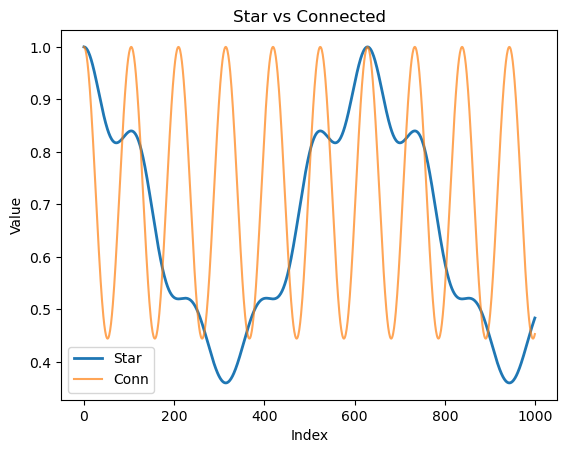

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Create a single plot (1 row, 1 column)
fig, ax = plt.subplots()

# Plot the first dataset
ax.plot(np.arange(len(Star_origin)), Star_origin, label="Star", linewidth=2)

# Plot the second dataset on the same 'ax'
ax.plot(np.arange(len(Conn_origin)), Conn_origin, label="Conn", alpha=0.7)

# Add styling and clarity
ax.set_title("Star vs Connected")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.legend() # This shows the labels we defined in the plot calls

plt.show()

## All the rotational thingies?

Let me try a wheel

In [70]:
import numpy as np                          # linear algebra

graph_size = 6

x = np.zeros(graph_size, dtype=np.complex128)  # position vector
x[0] = 1

state = x

Adjacence_wheel = np.zeros((graph_size, graph_size), dtype=np.complex128)

for i in range(graph_size-1):
    Adjacence_wheel[0, i+1] = 1
    Adjacence_wheel[i+1, 0] = 1

for i in range(graph_size-2):
    Adjacence_wheel[i+1 ,i+2] = 1
    Adjacence_wheel[i+2, i+1] = 1

Adjacence_wheel[1, graph_size-1] = 1
Adjacence_wheel[graph_size - 1, 1] = 1

diagonal = 3 * np.eye(graph_size, dtype=np.complex128)

diagonal[0, 0] = graph_size - 1


gamma = 1

Laplace_wheel = gamma * (diagonal - Adjacence_wheel)

In [71]:
Star_origin = Measure_site(state, 0, 10, 1000, Laplace_star)
Wheel_origin = Measure_site(state, 0, 10, 1000, Laplace_wheel)

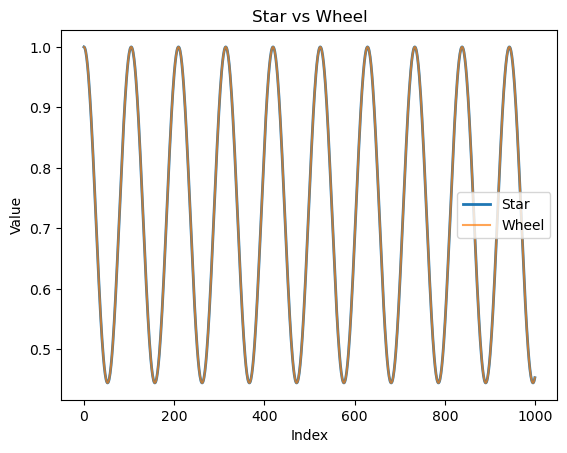

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Create a single plot (1 row, 1 column)
fig, ax = plt.subplots()

# Plot the first dataset
ax.plot(np.arange(len(Star_origin)), Star_origin, label="Star", linewidth=2)

# Plot the second dataset on the same 'ax'
ax.plot(np.arange(len(Wheel_origin)), Wheel_origin, label="Wheel", alpha=0.7)

# Add styling and clarity
ax.set_title("Star vs Wheel")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.legend() # This shows the labels we defined in the plot calls

plt.show()

In [73]:
t = 10

State_star = Evol_vector(t, state, Laplace_star)

pos_star = Measure_pos(State_star)

State_wheel= Evol_vector(t, state, Laplace_wheel)

pos_wheel = Measure_pos(State_wheel)

Text(0.5, 1.0, 'Connected')

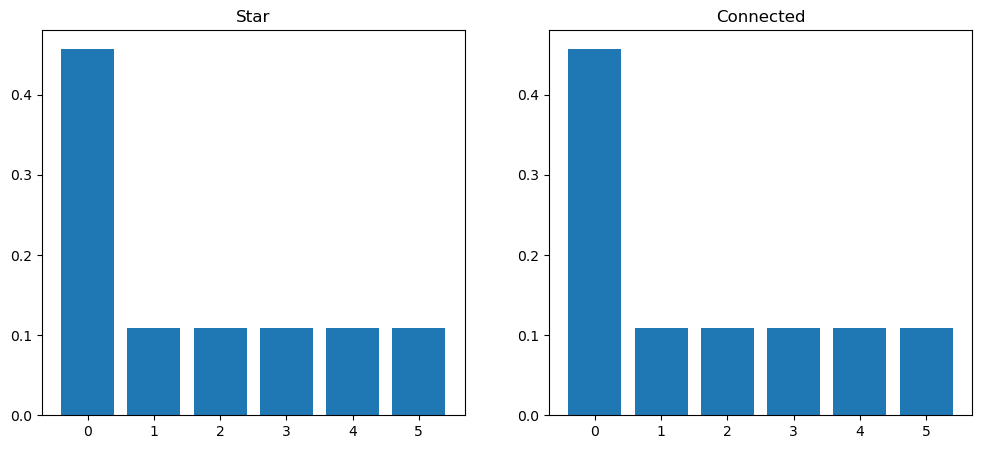

In [74]:
import matplotlib.pyplot as plt

fig, (p1, p2) = plt.subplots(1, 2, figsize=(12, 5))

p1.bar(np.arange(len(pos_star)), pos_star)

p1.set_title("Star")

p2.bar(np.arange(len(pos_wheel)), pos_wheel)

p2.set_title("Connected")

### with 8 sites now

In [79]:
import numpy as np                          # linear algebra

graph_size = 8

x = np.zeros(graph_size, dtype=np.complex128)  # position vector
x[0] = 1

state = x

In [80]:
Adjacence_wheel = np.zeros((graph_size, graph_size), dtype=np.complex128)

for i in range(graph_size-1):
    Adjacence_wheel[0, i+1] = 1
    Adjacence_wheel[i+1, 0] = 1

for i in range(graph_size-2):
    Adjacence_wheel[i+1 ,i+2] = 1
    Adjacence_wheel[i+2, i+1] = 1

Adjacence_wheel[1, graph_size-1] = 1
Adjacence_wheel[graph_size - 1, 1] = 1

diagonal = 3 * np.eye(graph_size, dtype=np.complex128)

diagonal[0, 0] = graph_size - 1


gamma = 1

Laplace_wheel = gamma * (diagonal - Adjacence_wheel)

In [81]:
Adj_conn = np.zeros((graph_size, graph_size), dtype=np.complex128)

Adj_conn.fill(1)

Adj_conn = Adj_conn - np.identity(graph_size)

diagonal = np.zeros((graph_size, graph_size), dtype=np.complex128)

for i in range (graph_size):
    diagonal[i, i] = graph_size - 1


gamma = 1

Laplace_conn = gamma * (diagonal - Adj_conn)

In [82]:
Adjacence_star = np.zeros((graph_size, graph_size), dtype=np.complex128)

for i in range(graph_size-1):
    Adjacence_star[0, i+1] = 1
    Adjacence_star[i+1, 0] = 1

diagonal = np.eye(graph_size, dtype=np.complex128)

diagonal[0, 0] = graph_size - 1


gamma = 1

Laplace_star = gamma * (diagonal - Adjacence_star)

In [83]:
Adjacence_wheel2 = np.zeros((graph_size, graph_size), dtype=np.complex128)

for i in range(graph_size-1):       #Raggi
    Adjacence_wheel2[0, i+1] = 1
    Adjacence_wheel2[i+1, 0] = 1

for i in range(graph_size-2):       #Circonferenza
    Adjacence_wheel2[i+1 ,i+2] = 1
    Adjacence_wheel2[i+2, i+1] = 1

Adjacence_wheel2[1, graph_size-1] = 1
Adjacence_wheel2[graph_size - 1, 1] = 1


for i in range(graph_size-3):       #Circonferenza
    Adjacence_wheel2[i+1 ,i+3] = 1
    Adjacence_wheel2[i+3, i+1] = 1

Adjacence_wheel2[1, graph_size-3] = 1
Adjacence_wheel2[graph_size - 3, 1] = 1

diagonal = 3 * np.eye(graph_size, dtype=np.complex128)

diagonal[0, 0] = graph_size - 1


gamma = 1

Laplace_wheel2 = gamma * (diagonal - Adjacence_wheel)

In [84]:
Star_origin = Measure_site(state, 0, 10, 1000, Laplace_star)
Wheel_origin = Measure_site(state, 0, 10, 1000, Laplace_wheel)
Conn_origin = Measure_site(state, 0, 10, 1000, Laplace_conn)
Wheel2_origin = Measure_site(state, 0, 10, 1000, Laplace_wheel2)

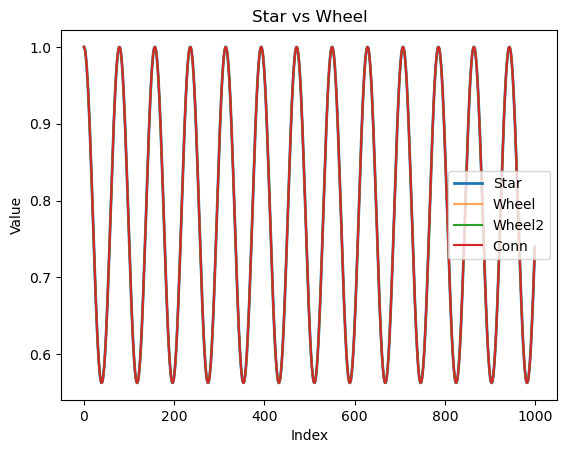

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# Create a single plot (1 row, 1 column)
fig, ax = plt.subplots()

# Plot the first dataset
ax.plot(np.arange(len(Star_origin)), Star_origin, label="Star", linewidth=2)

# Plot the second dataset on the same 'ax'
ax.plot(np.arange(len(Wheel_origin)), Wheel_origin, label="Wheel", alpha=0.7)

ax.plot(np.arange(len(Wheel2_origin)), Wheel2_origin, label="Wheel2")

ax.plot(np.arange(len(Conn_origin)), Conn_origin, label="Conn")

# Add styling and clarity
ax.set_title("Star vs Wheel")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.legend() # This shows the labels we defined in the plot calls

plt.show()

Palese dipende dalla simmetria rotante